In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Dropout
from keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, roc_curve, auc

import keras_tuner as kt 
from keras_tuner.tuners import RandomSearch, GridSearch

import warnings
warnings.filterwarnings("ignore")

2025-07-20 14:21:01.344208: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#veri seti yükle, imdb 50000, (0 => olumsuz) (1 => olumlu)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000) # num_words = en çok kullanılan 10000 kelimeyi al 

In [3]:
#veri ön işleme : yorumları aynı uzunluğa getirmek için padding yöntemi kullanılır
maxlen = 100
x_train = pad_sequences(x_train, maxlen) #train verisi uzunluğu ayarlama 
x_test = pad_sequences(x_test, maxlen) #test verisi uzunluğu ayarlama 

In [4]:
#create and compile RNN model 
def build_model(hp): # hp: hyperparameter
    model = Sequential() #base model
    #embedding katmanı: kelimeleri vektörlere dönüştüme
    model.add(Embedding(input_dim=10000,
                        output_dim = hp.Int("embedding_output", min_value = 32, max_value = 128, step = 32), #vektör boyutları 32, 64, p6, 128 olabilir
                        input_length = maxlen))
    #simpleRNN: rnn katmanı
    model.add(SimpleRNN(units = hp.Int("rnn_units", min_value = 32, max_value = 128, step = 32))) #rnn hücre sayısı 32, 64, 96, 128 olabilir
    #dropout katmanı: overfittingi engellemek için rastgele bazı cellleri kapatır
    model.add(Dropout(rate = hp.Float("dropout_rate", min_value = 0.2, max_value = 0.5, step = 0.1)))
    #çıktı katmanı: 1 cell ve sigmoid
    model.add(Dense(1, activation = "sigmoid")) #sigmoid activation: ikili sınıflandırma için kullanılır. Çıktı 0 ya da 1 arasında olur
    #modelin compile edilmesi
    model.compile(optimizer = hp.Choice("optimizer", ["adam", "rmsprop"]), #adam veya rmsprop kullanılabilir
                  loss = "binary_crossentropy",
                  metrics = ["accuracy", "AUC"]) #AUC: area under curve
    return model

In [5]:
#Hyperparameter search, model train
#hyperparameter search: random search ile hiperparametre aranacak, grid searchte kullanılabilir
tuner = RandomSearch(build_model, #optimize edilecek model fonksiyonu
                     objective = "val_accuracy", #val_loss en düşük olan en iyisidir, val_accuracy : yüksek olan en iyisidir
                     max_trials = 10, #iki farklı model denenecek,
                     executions_per_trial = 1, #her model için bir eğitim denemesi
                     directory = "rnn_tuner_directory", #modellerin kaydedileceği dizin
                     project_name = "imdb_rnn", #projenin adı
                     )

2025-07-20 14:21:17.289345: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
#erken durdurma: doğrulama hatası düzelmezse (azalmazsa) eğitimi durdurur
early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 3, restore_best_weights = True)

In [7]:
#modelin eğitimi 
tuner.search(x_train, y_train,
             epochs = 5,
             validation_split = 0.2,
             callbacks = [early_stopping])

Trial 10 Complete [00h 01m 04s]
val_accuracy: 0.7975999712944031

Best val_accuracy So Far: 0.8381999731063843
Total elapsed time: 00h 09m 46s


In [8]:
#evaluate best model
#en iyi modelin alınması
best_model = tuner.get_best_models(num_models=1)[0] # en iyi performans gösteren model 

In [9]:
#en iyi modeli kullanarak test et 
loss, accuracy, auc_score = best_model.evaluate(x_test, y_test)
print(f"Test loss: {loss}, test accuracy: {accuracy:.3f}, test auc: {auc_score:.3f}")

782/782 [==============================] - 4s 4ms/step - loss: 0.3931 - accuracy: 0.8322 - auc: 0.9073
Test loss: 0.39305898547172546, test accuracy: 0.832, test auc: 0.907


In [10]:
#tahmin yapma ve modelin performansını değerlendirme 
y_pred_prob = best_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32") #tahmin edilen değerler 0.5 den büyükse 1 e yuvarlanır

782/782 [==============================] - 3s 4ms/step


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83     12500
           1       0.83      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [12]:
#roc eğrisi hesaplama 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob) #roc eğrisi için fpr (false positive rate) ve tpr (true positive rate) hesaplar
roc_auc = auc(fpr, tpr) # roc eğrisinin altında kalan alandır. 1 e ne kadar yakınsa o kadar iyidir

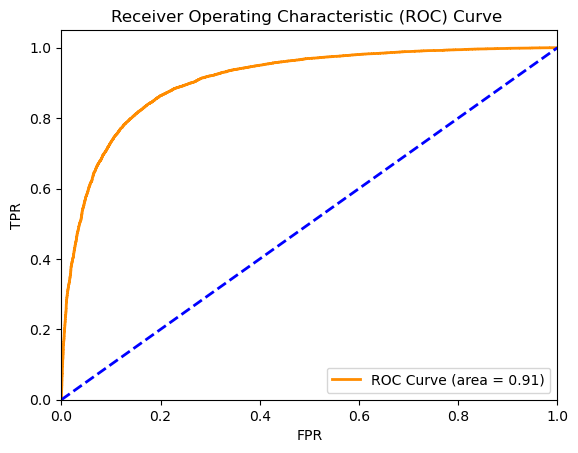

In [13]:
# roc eğrisi görselleştirme
plt.figure()
plt.plot(fpr, tpr, color = "darkorange", lw = 2, label = "ROC Curve (area = %0.2f)" %roc_auc) #roc curve
plt.plot([0,1], [0,1], color = "blue", lw = 2, linestyle = "--") #rasgele tahmin çizgisi
plt.xlim([0,1])
plt.ylim([0, 1.05])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Receiver Operating Characteristic (ROC) Curve ")
plt.legend()
plt.show()